<a href="https://colab.research.google.com/github/jorigo/Reto1_TelecomX/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# Ruta completa al archivo JSON en Google Drive
drive_file_path = '/content/drive/MyDrive/Colab Notebooks/Archivos_Pandas_DataBase/TelecomX_Data.json'

# Importar los datos desde el archivo JSON del Drive
df = pd.read_json(drive_file_path)

# Mostrar las primeras filas del DataFrame para verificar la importación
print(df.head())

   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL', 'OnlineSecurity': '...   
2  {'InternetService': 'Fiber optic', 'OnlineSecu...   
3  {'I

#🔧 Transformación

In [6]:
# Aplanar la columna 'phone'
df_phone = pd.json_normalize(df['phone'])
df = pd.concat([df.drop(columns=['phone']), df_phone], axis=1)

# Aplanar la columna 'internet'
df_internet = pd.json_normalize(df['internet'])
df = pd.concat([df.drop(columns=['internet']), df_internet], axis=1)

# Aplanar la columna 'account'
df_account = pd.json_normalize(df['account'])
df = pd.concat([df.drop(columns=['account']), df_account], axis=1)

print("DataFrame después de aplanar todas las columnas anidadas:")
print(df.head())
print(df.info())
print(df.dtypes)

DataFrame después de aplanar todas las columnas anidadas:
   customerID Churn  gender  SeniorCitizen Partner Dependents  tenure  \
0  0002-ORFBO    No  Female              0     Yes        Yes       9   
1  0003-MKNFE    No    Male              0      No         No       9   
2  0004-TLHLJ   Yes    Male              0      No         No       4   
3  0011-IGKFF   Yes    Male              1     Yes         No      13   
4  0013-EXCHZ   Yes  Female              1     Yes         No       3   

  PhoneService MultipleLines InternetService  ... OnlineBackup  \
0          Yes            No             DSL  ...          Yes   
1          Yes           Yes             DSL  ...           No   
2          Yes            No     Fiber optic  ...           No   
3          Yes            No     Fiber optic  ...          Yes   
4          Yes            No     Fiber optic  ...           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No         Y

In [7]:
# 1. Corrección de formato para 'Charges.Total'
# Reemplazar valores vacíos con NaN y convertir a numérico
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

print("\nDespués de corregir 'Charges.Total':")
print(df[['Charges.Total']].head())
print(df['Charges.Total'].dtype)

# 2. Verificación de valores ausentes
print("\nValores ausentes por columna:")
print(df.isnull().sum())

# 3. Verificación de duplicados
print("\nNúmero de filas duplicadas:")
print(df.duplicated().sum())

# 4. Verificación de inconsistencias en categorías (columnas tipo 'object')
print("\nValores únicos en columnas categóricas (primeros 10 por columna):")
for column in df.select_dtypes(include='object').columns:
    if column not in ['customerID']:
        unique_values = df[column].unique()
        print(f"- {column}: {unique_values[:10]}")
        if len(unique_values) > 10:
            print(f"  (y {len(unique_values) - 10} más)")


Después de corregir 'Charges.Total':
   Charges.Total
0         593.30
1         542.40
2         280.85
3        1237.85
4         267.40
float64

Valores ausentes por columna:
customerID           0
Churn                0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
Charges.Monthly      0
Charges.Total       11
dtype: int64

Número de filas duplicadas:
0

Valores únicos en columnas categóricas (primeros 10 por columna):
- Churn: ['No' 'Yes' '']
- gender: ['Female' 'Male']
- Partner: ['Yes' 'No']
- Dependents: ['Yes' 'No']
- PhoneService: ['Yes' 'No']
- MultipleLines: ['No' 'Yes' 'No phone service']
- InternetService: ['DSL' 'Fiber optic' 'No']

In [8]:
# 1. borrar valores NaN en 'Charges.Total' con la mediana
median_charges_total = df['Charges.Total'].median()
df['Charges.Total'].fillna(median_charges_total, inplace=True)
print(f"Valores NaN en 'Charges.Total' después de la imputación: {df['Charges.Total'].isnull().sum()}")

# 2. Corregir inconsistencia en la columna 'Churn': reemplazar '' con 'No'
df['Churn'] = df['Churn'].replace('', 'No')
print(f"Valores únicos en 'Churn' después de la corrección: {df['Churn'].unique()}")

# 3. Demostrar string manipulation (.lower()) en algunas columnas categóricas
for col in ['gender', 'Contract']:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].str.lower()
        print(f"Valores únicos en '{col}' después de .lower(): {df[col].unique()}")

print("\nVerificación final de valores ausentes:")
print(df.isnull().sum())

print("\nDataFrame después de las correcciones (primeras 5 filas):")
print(df.head())

Valores NaN en 'Charges.Total' después de la imputación: 0
Valores únicos en 'Churn' después de la corrección: ['No' 'Yes']
Valores únicos en 'gender' después de .lower(): ['female' 'male']
Valores únicos en 'Contract' después de .lower(): ['one year' 'month-to-month' 'two year']

Verificación final de valores ausentes:
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64

DataFrame después de las correcciones (primeras 5 filas):
   customerID Churn  gender  SeniorCitizen Partner Dependents  tenure  \
0  0002-ORFBO    No  female              0     Yes        Yes       9  

/tmp/ipykernel_275/439490661.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Charges.Total'].fillna(median_charges_total, inplace=True)


In [9]:
# Crear la columna 'Cuentas_Diarias' a partir de 'Charges.Monthly'
df['Cuentas_Diarias'] = df['Charges.Monthly'] / 30

print("DataFrame con la nueva columna 'Cuentas_Diarias' (primeras 5 filas):")
print(df[['Charges.Monthly', 'Cuentas_Diarias']].head())
print(f"Tipo de dato de 'Cuentas_Diarias': {df['Cuentas_Diarias'].dtype}")

DataFrame con la nueva columna 'Cuentas_Diarias' (primeras 5 filas):
   Charges.Monthly  Cuentas_Diarias
0             65.6         2.186667
1             59.9         1.996667
2             73.9         2.463333
3             98.0         3.266667
4             83.9         2.796667
Tipo de dato de 'Cuentas_Diarias': float64


In [10]:
# Mapeo de valores binarios estándar (Sí/No a 1/0)
binary_map = {'Yes': 1, 'No': 0}

# Columnas con solo 'Yes'/'No' que se binarizarán directamente
cols_to_binarize_simple = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in cols_to_binarize_simple:
    df[col] = df[col].map(binary_map)

# Columna 'gender': Mapear 'female' a 0 y 'male' a 1
df['gender'] = df['gender'].map({'female': 0, 'male': 1})

# Columnas con 'No service' que se binarizarán (Yes=1, No/No service=0)
cols_with_no_service_to_binarize = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in cols_with_no_service_to_binarize:
    # Reemplazar los valores de 'No service' por 'No' antes de mapear
    df[col] = df[col].replace({'No phone service': 'No', 'No internet service': 'No'}).map(binary_map)

# Renombrar columnas a español para mayor claridad
new_column_names = {
    'customerID': 'ID_Cliente',
    'Churn': 'Abandono',
    'gender': 'Genero',
    'SeniorCitizen': 'Ciudadano_Senior',
    'Partner': 'Pareja',
    'Dependents': 'Dependientes',
    'tenure': 'Antiguedad_Meses',
    'PhoneService': 'Servicio_Telefonico',
    'MultipleLines': 'Multiples_Lineas',
    'InternetService': 'Servicio_Internet', # Mantener como categórica por ahora
    'OnlineSecurity': 'Seguridad_Online',
    'OnlineBackup': 'Copia_Seguridad_Online',
    'DeviceProtection': 'Proteccion_Dispositivo',
    'TechSupport': 'Soporte_Tecnico',
    'StreamingTV': 'Television_Streaming',
    'StreamingMovies': 'Peliculas_Streaming',
    'Contract': 'Contrato', # Mantener como categórica por ahora
    'PaperlessBilling': 'Facturacion_Sin_Papel',
    'PaymentMethod': 'Metodo_Pago', # Mantener como categórica por ahora
    'Charges.Monthly': 'Cargos_Mensuales',
    'Charges.Total': 'Cargos_Totales',
    'Cuentas_Diarias': 'Cargos_Diarios'
}

df = df.rename(columns=new_column_names)

print("\nDataFrame después de binarizar y renombrar (primeras 5 filas):")
print(df.head())
print("\nTipos de datos después de la transformación:")
print(df.dtypes)
print("\nValores únicos en algunas columnas binarizadas para verificación:")
print(f"Abandono: {df['Abandono'].unique()}")
print(f"Genero: {df['Genero'].unique()}")
print(f"Servicio_Telefonico: {df['Servicio_Telefonico'].unique()}")
print(f"Seguridad_Online: {df['Seguridad_Online'].unique()}")


DataFrame después de binarizar y renombrar (primeras 5 filas):
   ID_Cliente  Abandono  Genero  Ciudadano_Senior  Pareja  Dependientes  \
0  0002-ORFBO         0       0                 0       1             1   
1  0003-MKNFE         0       1                 0       0             0   
2  0004-TLHLJ         1       1                 0       0             0   
3  0011-IGKFF         1       1                 1       1             0   
4  0013-EXCHZ         1       0                 1       1             0   

   Antiguedad_Meses  Servicio_Telefonico  Multiples_Lineas Servicio_Internet  \
0                 9                    1                 0               DSL   
1                 9                    1                 1               DSL   
2                 4                    1                 0       Fiber optic   
3                13                    1                 0       Fiber optic   
4                 3                    1                 0       Fiber optic   

   .

#📊 Carga y análisis

In [11]:
print("\nAnálisis Descriptivo de los Datos:")
print(df.describe())


Análisis Descriptivo de los Datos:
          Abandono       Genero  Ciudadano_Senior       Pareja  Dependientes  \
count  7267.000000  7267.000000       7267.000000  7267.000000   7267.000000   
mean      0.257190     0.505711          0.162653     0.484106      0.300124   
std       0.437115     0.500002          0.369074     0.499782      0.458343   
min       0.000000     0.000000          0.000000     0.000000      0.000000   
25%       0.000000     0.000000          0.000000     0.000000      0.000000   
50%       0.000000     1.000000          0.000000     0.000000      0.000000   
75%       1.000000     1.000000          0.000000     1.000000      1.000000   
max       1.000000     1.000000          1.000000     1.000000      1.000000   

       Antiguedad_Meses  Servicio_Telefonico  Multiples_Lineas  \
count       7267.000000          7267.000000       7267.000000   
mean          32.346498             0.902711          0.421770   
std           24.571773             0.296371 

/tmp/ipykernel_275/1180074883.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Abandono', data=df, palette='viridis')


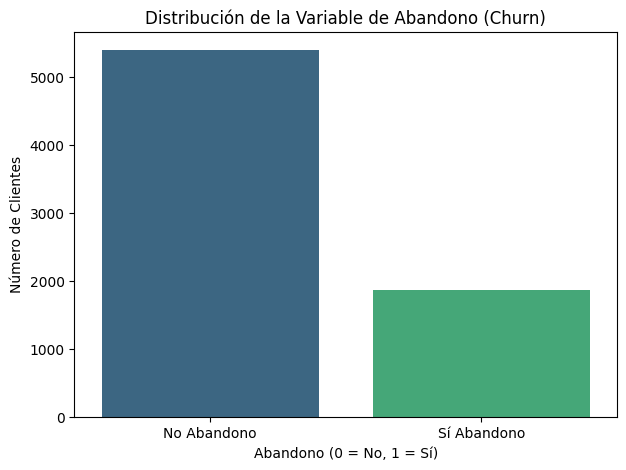

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(x='Abandono', data=df, palette='viridis')
plt.title('Distribución de la Variable de Abandono (Churn)')
plt.xlabel('Abandono (0 = No, 1 = Sí)')
plt.ylabel('Número de Clientes')
plt.xticks(ticks=[0, 1], labels=['No Abandono', 'Sí Abandono'])
plt.show()

#📄Informe final